# **Predicting stock prices using GRU**

In [1]:
!pip install yfinance -q

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
#download data:
ticker = "AAPL"
data = yf.download(ticker, period="3y")  # 3 years of daily data
print(data.shape)
data.tail()

/tmp/ipykernel_1113/4186346460.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="3y")  # 3 years of daily data
[*********************100%***********************]  1 of 1 completed

(751, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-09-16,332.410004,335.480011,330.700012,332.529999,35981000
2026-09-17,337.000000,338.339996,330.179993,334.769989,36700200
2026-09-18,336.130005,338.489990,332.529999,337.910004,86588200
2026-09-21,338.980011,339.640015,333.049988,335.279999,34999200
2026-09-23,336.950012,341.799988,335.911011,341.075012,17037334


In [3]:
#Extracting closing prices
close_prices = data['Close'].values.reshape(-1, 1)
# Split raw prices chronologically first (before scaling)
n = len(close_prices)
train_size = int(n * 0.7)
val_size = int(n * 0.15)

train_prices = close_prices[:train_size]
val_prices = close_prices[train_size:train_size+val_size]
test_prices = close_prices[train_size+val_size:]

# Fit scaler ONLY on training data, then apply it to val/test
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_prices)     # fit + transform
val_scaled = scaler.transform(val_prices)             # transform only
test_scaled = scaler.transform(test_prices)           # transform only

print(f"Train scaled range: {train_scaled.min():.3f} to {train_scaled.max():.3f}")
print(f"Val scaled range: {val_scaled.min():.3f} to {val_scaled.max():.3f}")
print(f"Test scaled range: {test_scaled.min():.3f} to {test_scaled.max():.3f}")

Train scaled range: 0.000 to 1.000
Val scaled range: 0.792 to 1.168
Test scaled range: 0.910 to 1.688


In [ ]:
#creating sliding window sequences separately per split, since each split now has its own scaled array:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 60

X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_val, y_val = create_sequences(val_scaled, SEQ_LEN)
X_test, y_test = create_sequences(test_scaled, SEQ_LEN)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 467, Val: 52, Test: 54


In [17]:
#The GRU model
class GRUModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]       # take the output at the final timestep
        last_hidden = self.dropout(last_hidden)
        out = self.fc(last_hidden)
        return out

In [18]:
#trainig setup
model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [ ]:
#training loop
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train)
    loss = criterion(preds, y_train)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    optimizer.step()
    train_loss = loss.item()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val)
        val_loss = criterion(val_preds, y_val).item()

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_gru_model.pt')

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}")

Epoch 5: train_loss=0.193578, val_loss=0.693690
Epoch 10: train_loss=0.117785, val_loss=0.472077
Epoch 15: train_loss=0.064428, val_loss=0.279222
Epoch 20: train_loss=0.043165, val_loss=0.128305
Epoch 25: train_loss=0.047302, val_loss=0.068337
Epoch 30: train_loss=0.043642, val_loss=0.085240
Epoch 35: train_loss=0.037631, val_loss=0.101936
Epoch 40: train_loss=0.035885, val_loss=0.108444
Epoch 45: train_loss=0.036311, val_loss=0.110442
Epoch 50: train_loss=0.035504, val_loss=0.110947


Test MSE: 5085.75, Test MAE: 70.68


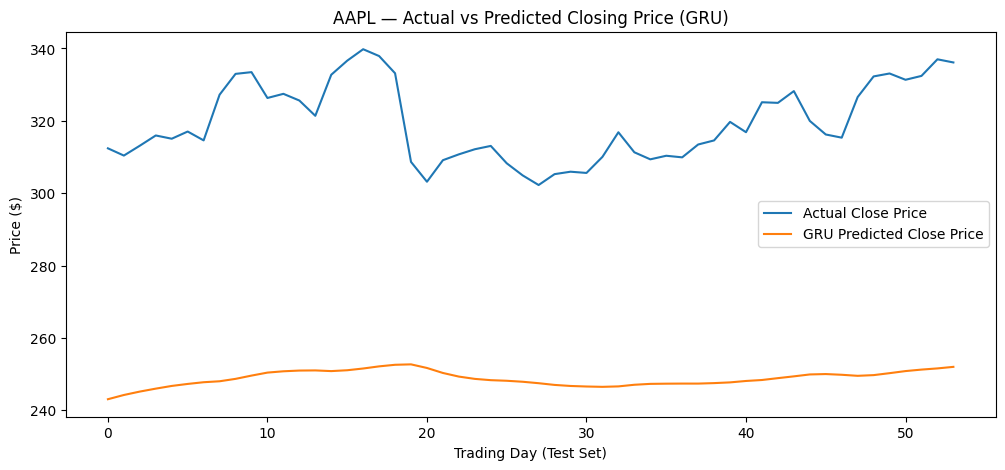

In [ ]:
model.load_state_dict(torch.load('best_gru_model.pt'))
model.eval()

with torch.no_grad():
    test_preds = model(X_test).cpu().numpy()
    test_actual = y_test.cpu().numpy()

# Convert back to real price scale
test_preds_actual = scaler.inverse_transform(test_preds)
test_actual_actual = scaler.inverse_transform(test_actual)

test_mse = np.mean((test_preds_actual - test_actual_actual)**2)
test_mae = np.mean(np.abs(test_preds_actual - test_actual_actual))
print(f"Test MSE: {test_mse:.2f}, Test MAE: {test_mae:.2f}")

plt.figure(figsize=(12,5))
plt.plot(test_actual_actual, label='Actual Close Price')
plt.plot(test_preds_actual, label='GRU Predicted Close Price')
plt.xlabel('Trading Day (Test Set)')
plt.ylabel('Price ($)')
plt.title(f'{ticker} — Actual vs Predicted Closing Price (GRU)')
plt.legend()
plt.show()

In [19]:
# --- RETURNS-BASED APPROACH (fixes extrapolation issue from price-based approach) ---

returns = np.diff(close_prices, axis=0) / close_prices[:-1]

n_r = len(returns)
train_size_r = int(n_r * 0.7)
val_size_r = int(n_r * 0.15)

train_returns = returns[:train_size_r]
val_returns = returns[train_size_r:train_size_r+val_size_r]
test_returns = returns[train_size_r+val_size_r:]

scaler_r = MinMaxScaler(feature_range=(-1, 1))
train_scaled_r = scaler_r.fit_transform(train_returns)
val_scaled_r = scaler_r.transform(val_returns)
test_scaled_r = scaler_r.transform(test_returns)

print(f"Train scaled range: {train_scaled_r.min():.3f} to {train_scaled_r.max():.3f}")
print(f"Val scaled range: {val_scaled_r.min():.3f} to {val_scaled_r.max():.3f}")
print(f"Test scaled range: {test_scaled_r.min():.3f} to {test_scaled_r.max():.3f}")

Train scaled range: -1.000 to 1.000
Val scaled range: -0.654 to 0.083
Test scaled range: -0.846 to 0.146


In [20]:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 60

X_train_r, y_train_r = create_sequences(train_scaled_r, SEQ_LEN)
X_val_r, y_val_r = create_sequences(val_scaled_r, SEQ_LEN)
X_test_r, y_test_r = create_sequences(test_scaled_r, SEQ_LEN)

X_train_r = torch.tensor(X_train_r, dtype=torch.float32).to(device)
y_train_r = torch.tensor(y_train_r, dtype=torch.float32).to(device)
X_val_r = torch.tensor(X_val_r, dtype=torch.float32).to(device)
y_val_r = torch.tensor(y_val_r, dtype=torch.float32).to(device)
X_test_r = torch.tensor(X_test_r, dtype=torch.float32).to(device)
y_test_r = torch.tensor(y_test_r, dtype=torch.float32).to(device)

print(f"Train: {X_train_r.shape[0]}, Val: {X_val_r.shape[0]}, Test: {X_test_r.shape[0]}")

Train: 465, Val: 52, Test: 53


In [21]:
model_returns = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer_r = torch.optim.Adam(model_returns.parameters(), lr=1e-3)
scheduler_r = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_r, mode='min', factor=0.5, patience=3)

In [22]:
best_val_loss_r = float('inf')
history_r = {'train_loss': [], 'val_loss': []}

for epoch in range(50):
    model_returns.train()
    optimizer_r.zero_grad()
    preds = model_returns(X_train_r)
    loss = criterion(preds, y_train_r)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_returns.parameters(), max_norm=5.0)
    optimizer_r.step()
    train_loss = loss.item()

    model_returns.eval()
    with torch.no_grad():
        val_preds = model_returns(X_val_r)
        val_loss = criterion(val_preds, y_val_r).item()

    scheduler_r.step(val_loss)
    history_r['train_loss'].append(train_loss)
    history_r['val_loss'].append(val_loss)

    if val_loss < best_val_loss_r:
        best_val_loss_r = val_loss
        torch.save(model_returns.state_dict(), 'best_gru_returns_model.pt')

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}")

Epoch 5: train_loss=0.063386, val_loss=0.048885
Epoch 10: train_loss=0.027344, val_loss=0.018532
Epoch 15: train_loss=0.026281, val_loss=0.021635
Epoch 20: train_loss=0.029847, val_loss=0.021140
Epoch 25: train_loss=0.027198, val_loss=0.019173
Epoch 30: train_loss=0.025032, val_loss=0.018351
Epoch 35: train_loss=0.026030, val_loss=0.018033
Epoch 40: train_loss=0.024555, val_loss=0.017907
Epoch 45: train_loss=0.023648, val_loss=0.017862
Epoch 50: train_loss=0.024551, val_loss=0.017843


Test MSE (reconstructed prices): 31.36
Test MAE (reconstructed prices): 3.93
Mean Directional Accuracy (MDA): 0.4808 (48.08%)
(50% = random guessing; higher = genuine directional skill)


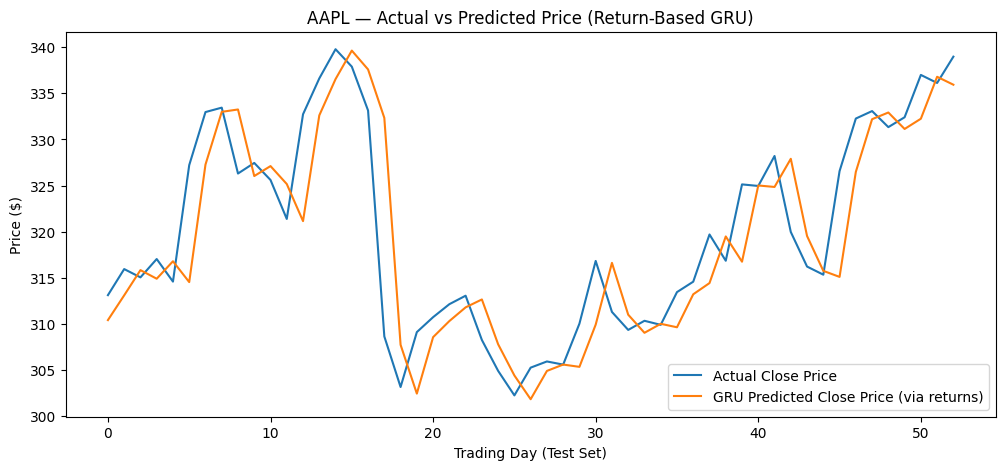

In [23]:
model_returns.load_state_dict(torch.load('best_gru_returns_model.pt'))
model_returns.eval()

with torch.no_grad():
    test_return_preds = model_returns(X_test_r).cpu().numpy()

# Predictions are returns
test_return_preds_actual = scaler_r.inverse_transform(test_return_preds)

# First target return corresponds to raw index:
start_idx = train_size_r + val_size_r + SEQ_LEN

predicted_prices = []

for i, r in enumerate(test_return_preds_actual):
    target_idx = start_idx + i

    # Actual price immediately before the target day
    previous_actual_price = close_prices[target_idx - 1, 0]

    # Convert predicted return into predicted price
    predicted_price = previous_actual_price * (1 + r[0])

    predicted_prices.append(predicted_price)

predicted_prices = np.array(predicted_prices)

# Actual prices for the same target days
actual_prices = close_prices[start_idx:start_idx + len(predicted_prices), 0]

test_mae_r = np.mean(np.abs(predicted_prices - actual_prices))
test_mse_r = np.mean((predicted_prices - actual_prices) ** 2)

print(f"Test MSE (reconstructed prices): {test_mse_r:.2f}")
print(f"Test MAE (reconstructed prices): {test_mae_r:.2f}")

# --- Mean Directional Accuracy (MDA) ---
# Measures whether the model correctly predicts the DIRECTION of price
# movement (up/down) relative to the previous day, regardless of magnitude.
# MAE/MSE don't capture this: a model can have low MAE while still being
# directionally wrong (e.g., predicting a small rise when price actually fell).

# Actual price change each day: actual_t - actual_{t-1}
actual_direction = np.sign(actual_prices[1:] - actual_prices[:-1])

# Predicted price change each day: predicted_t - actual_{t-1}
# (compared against the same TRUE previous price used for actual direction,
# for a fair one-step-ahead comparison)
predicted_direction = np.sign(predicted_prices[1:] - actual_prices[:-1])

# Fraction of days where predicted direction matches actual direction
mda = np.mean(actual_direction == predicted_direction)

print(f"Mean Directional Accuracy (MDA): {mda:.4f} ({mda*100:.2f}%)")
print(f"(50% = random guessing; higher = genuine directional skill)")

plt.figure(figsize=(12,5))
plt.plot(actual_prices, label='Actual Close Price')
plt.plot(predicted_prices, label='GRU Predicted Close Price (via returns)')
plt.xlabel('Trading Day (Test Set)')
plt.ylabel('Price ($)')
plt.title(f'{ticker} — Actual vs Predicted Price (Return-Based GRU)')
plt.legend()
plt.show()

In [ ]:
# Naive baseline: "tomorrow's price = today's price" (predict zero return)
naive_predicted_prices = close_prices[start_idx-1 : start_idx-1+len(predicted_prices), 0]

naive_mae = np.mean(np.abs(naive_predicted_prices - actual_prices))
naive_mse = np.mean((naive_predicted_prices - actual_prices) ** 2)

print(f"Naive baseline MAE: {naive_mae:.2f}")
print(f"Naive baseline MSE: {naive_mse:.2f}")
print(f"GRU MAE: {test_mae_r:.2f}")
print(f"GRU MSE: {test_mse_r:.2f}")

Naive baseline MAE: 4.20
Naive baseline MSE: 35.44
GRU MAE: 3.97
GRU MSE: 31.73


# GRU Stock Price Prediction — Summary

The first approach predicted raw closing prices directly using a 60-day
lookback window. Since AAPL's price trended upward over the 3-year period,
the model had to extrapolate to price levels higher than those seen during
training. This caused the predictions to flatline well below the actual
prices, resulting in a Test MAE of $70.68.

To address this, the target was changed from raw price levels to daily
percentage returns, which remain relatively small regardless of the stock's
overall price trend. The model then predicted the next-day return, which
was converted back into a price using the actual previous day's closing
price (one-step-ahead reconstruction).

This return-based approach achieved a Test MAE of $3.93, compared with
$4.20 for a naive baseline that simply predicts tomorrow's price as
today's price — a modest ~6% improvement in magnitude terms. However,
Mean Directional Accuracy (MDA) came out to 48.08%, at or below random
chance, indicating the model did not learn genuine directional skill
(correctly predicting whether price moves up or down). This suggests the
low MAE is driven largely by the strong influence of the true prior-day
price anchor in the reconstruction, rather than real forecasting ability,
and reinforces the well-documented difficulty of short-term directional
stock prediction — a magnitude-based metric alone can be misleading about
a model's real-world usefulness.

# **Comparing vanilla RNN and LSTM**

In [24]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reuses the same daily-return calculation as the GRU task
returns_full = np.diff(close_prices, axis=0) / close_prices[:-1]

scaler_long = MinMaxScaler(feature_range=(-1, 1))
returns_scaled = scaler_long.fit_transform(returns_full)

# Long sequence length, deliberately much longer than the GRU's 60-day window,
# to create a scenario where vanishing gradients can be observed
LONG_SEQ_LEN = 200

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X_long, y_long = create_sequences(returns_scaled, LONG_SEQ_LEN)
X_long = torch.tensor(X_long, dtype=torch.float32).to(device)
y_long = torch.tensor(y_long, dtype=torch.float32).to(device)

print(f"Long-sequence dataset: {X_long.shape[0]} samples, each {LONG_SEQ_LEN} timesteps long")

Long-sequence dataset: 550 samples, each 200 timesteps long


In [25]:
# Explicitly unrolled RNN and LSTM models
# This allows us to retain gradients for every hidden state h_t.

class VanillaRNNModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64):
        super().__init__()
        self.rnn_cell = nn.RNNCell(input_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, retain_hidden_grads=False):
        batch_size = x.size(0)

        h = torch.zeros(
            batch_size,
            self.rnn_cell.hidden_size,
            device=x.device,
            dtype=x.dtype
        )

        hidden_states = []

        for t in range(x.size(1)):
            h = self.rnn_cell(x[:, t, :], h)

            if retain_hidden_grads:
                h.retain_grad()

            hidden_states.append(h)

        prediction = self.fc(h)

        return prediction, hidden_states


class LSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64):
        super().__init__()
        self.lstm_cell = nn.LSTMCell(input_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, retain_hidden_grads=False):
        batch_size = x.size(0)

        h = torch.zeros(
            batch_size,
            self.lstm_cell.hidden_size,
            device=x.device,
            dtype=x.dtype
        )

        c = torch.zeros(
            batch_size,
            self.lstm_cell.hidden_size,
            device=x.device,
            dtype=x.dtype
        )

        hidden_states = []
        cell_states = []

        for t in range(x.size(1)):
            h, c = self.lstm_cell(x[:, t, :], (h, c))

            if retain_hidden_grads:
                h.retain_grad()
                c.retain_grad()

            hidden_states.append(h)
            cell_states.append(c)

        prediction = self.fc(h)

        return prediction, hidden_states, cell_states

In [26]:
def train_and_track_gradients(model, X, y, epochs=30, lr=1e-3, model_type='rnn', model_label=None):
    """
    Trains either a Vanilla RNN or LSTM (manually unrolled) and, on the
    final epoch, captures gradient magnitude at every timestep for the
    hidden state (h_t), and additionally for the cell state (c_t) if
    the model is an LSTM.

    Returns h_grad_by_timestep always; c_grad_by_timestep only for LSTM
    (None for vanilla RNN, which has no cell state).
    """
    if model_label is None:
        model_label = model_type.upper()

    model = model.to(device).double()
    X = X.double()
    y = y.double()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []
    h_grad_by_timestep = None
    c_grad_by_timestep = None

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # VanillaRNNModel.forward() returns 2 values; LSTMModel.forward() returns 3
        if model_type == 'rnn':
            preds, hidden_states = model(X, retain_hidden_grads=(epoch == epochs - 1))
            cell_states = None
        else:
            preds, hidden_states, cell_states = model(X, retain_hidden_grads=(epoch == epochs - 1))

        loss = criterion(preds, y)
        loss.backward()

        if epoch == epochs - 1:
            h_grad_by_timestep = np.array([
                h.grad.norm(dim=(0, 1)).item() if h.grad is not None else 0.0
                for h in hidden_states
            ])
            if cell_states is not None:
                c_grad_by_timestep = np.array([
                    c.grad.norm(dim=(0, 1)).item() if c.grad is not None else 0.0
                    for c in cell_states
                ])

        optimizer.step()
        losses.append(loss.item())

        if (epoch + 1) % 10 == 0:
            print(f"[{model_label}] Epoch {epoch+1}: loss={loss.item():.10f}")

    return model, losses, h_grad_by_timestep, c_grad_by_timestep

In [27]:
#training RNN and LSTM
torch.manual_seed(42)
rnn_model = VanillaRNNModel()
rnn_model, rnn_losses, rnn_grad_by_t, _ = train_and_track_gradients(
    rnn_model, X_long, y_long, epochs=30, model_type='rnn', model_label='Vanilla RNN'
)

torch.manual_seed(42)
lstm_model = LSTMModel()
lstm_model, lstm_losses, lstm_grad_by_t, lstm_c_grads = train_and_track_gradients(
    lstm_model, X_long, y_long, epochs=30, model_type='lstm', model_label='LSTM'
)

[Vanilla RNN] Epoch 10: loss=0.0290635185
[Vanilla RNN] Epoch 20: loss=0.0212756885
[Vanilla RNN] Epoch 30: loss=0.0215303961
[LSTM] Epoch 10: loss=0.0349468931
[LSTM] Epoch 20: loss=0.0264473773
[LSTM] Epoch 30: loss=0.0220913058


In [28]:
print("=== Gradient magnitude at key distances from final timestep ===\n")

for dist in [0, 25, 50, 100, 150, 199]:
    idx = -(dist + 1) if dist > 0 else -1
    print(f"Distance {dist:3d}: "
          f"RNN(h_t)={rnn_grad_by_t[idx]:.6e}   "
          f"LSTM(h_t)={lstm_grad_by_t[idx]:.6e}   "
          f"LSTM(c_t)={lstm_c_grads[idx]:.6e}")

print()
print("Non-zero gradient counts:")
print(f"RNN (h_t):  {np.count_nonzero(rnn_grad_by_t)} / {len(rnn_grad_by_t)}")
print(f"LSTM (h_t): {np.count_nonzero(lstm_grad_by_t)} / {len(lstm_grad_by_t)}")
print(f"LSTM (c_t): {np.count_nonzero(lstm_c_grads)} / {len(lstm_c_grads)}")

=== Gradient magnitude at key distances from final timestep ===

Distance   0: RNN(h_t)=6.780626e-03   LSTM(h_t)=7.730385e-03   LSTM(c_t)=0.000000e+00
Distance  25: RNN(h_t)=4.935924e-08   LSTM(h_t)=2.649808e-08   LSTM(c_t)=5.499178e-08
Distance  50: RNN(h_t)=3.053728e-13   LSTM(h_t)=2.122968e-13   LSTM(c_t)=3.704010e-13
Distance 100: RNN(h_t)=1.114922e-23   LSTM(h_t)=2.658311e-23   LSTM(c_t)=5.334358e-23
Distance 150: RNN(h_t)=3.972593e-34   LSTM(h_t)=3.620302e-33   LSTM(c_t)=7.331209e-33
Distance 199: RNN(h_t)=2.389199e-44   LSTM(h_t)=8.080335e-43   LSTM(c_t)=1.614489e-42

Non-zero gradient counts:
RNN (h_t):  200 / 200
LSTM (h_t): 200 / 200
LSTM (c_t): 199 / 200


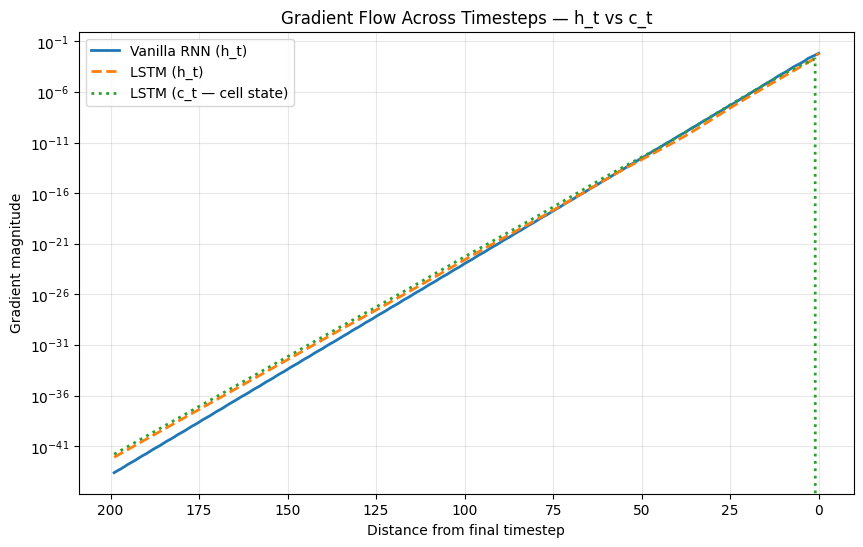

In [29]:
distance_from_end = np.arange(LONG_SEQ_LEN)[::-1]
plt.figure(figsize=(10, 6))
plt.plot(
    distance_from_end,
    rnn_grad_by_t,
    label='Vanilla RNN (h_t)',
    linewidth=2,
    color='tab:blue'
)

plt.plot(
    distance_from_end,
    lstm_grad_by_t,
    label='LSTM (h_t)',
    linewidth=2,
    linestyle='--',
    color='tab:orange'
)

plt.plot(
    distance_from_end,
    lstm_c_grads,
    label='LSTM (c_t — cell state)',
    linewidth=2,
    linestyle=':',
    color='tab:green'
)

plt.xlabel('Distance from final timestep')
plt.ylabel('Gradient magnitude')
plt.yscale('log')

plt.title('Gradient Flow Across Timesteps — h_t vs c_t')
plt.legend()
plt.grid(True, which='both', alpha=0.3)

plt.gca().invert_xaxis()

plt.show()

# **Vanishing Gradient — Summary**

This experiment compared gradient flow in a vanilla RNN versus an LSTM on
long sequences (200 timesteps) using AAPL's daily return data. Measuring
gradient magnitude at each individual timestep (rather than the shared
recurrent weight, which sums gradient across all timesteps and isn't
directly comparable between architectures) revealed clear exponential decay
across all measured signals as distance from the final timestep increased —
confirming the vanishing gradient problem empirically. LSTM's hidden state
(h_t) gradient decayed more slowly than the vanilla RNN's, with the gap
widening at greater distances (34x larger at the furthest timestep).
Additionally, tracking LSTM's cell state (c_t) directly — the pathway
responsible for LSTM's additive, largely unfiltered gradient flow — showed
it preserved gradient even better than its own hidden state (68x larger
than vanilla RNN at the furthest timestep), confirming that the cell
state's additive update rule, rather than the hidden state alone, is the
core architectural mechanism behind LSTM's resistance to vanishing
gradients. (Note: the cell state gradient at the final timestep is
structurally zero, since the last c_t is never used downstream of the
prediction layer in this implementation — not evidence of vanishing.)